## Trabajo Práctico 3 - Probabilidad multidimensional

7. **(Para entregar)** Simular una variable aleatoria $X = (X_1, X_2)$ que sigue una distribución binormal con parámetros $\mu_1 = 2.3$,  $\mu_2 = 1.5$, $\sigma_1 = 1.2$, $\sigma_2 = 0.5$ y correlación $\rho = 0.7$. Repetir la simulación 1000 veces. Calcular la fracción de eventos caen en la elipse $1\sigma$ y comparar con la probabilidad contenida dentro de dicha región. Graficar 10 de los datos simulados junto a la elipse 1σ.

Nota: un punto $(x_1, x_2)$ pertenece a la elipse $r\sigma$ si la forma cuadrática asociada $q(x_1, x_2) ≤ r$.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import danatools

Text(0.5, 1.0, 'Datos simulados de variable binormal, $\\mu_1 = 2.3$,  $\\mu_2 = 1.5$, $\\sigma_1 = 1.2$, $\\sigma_2 = 0.5$')

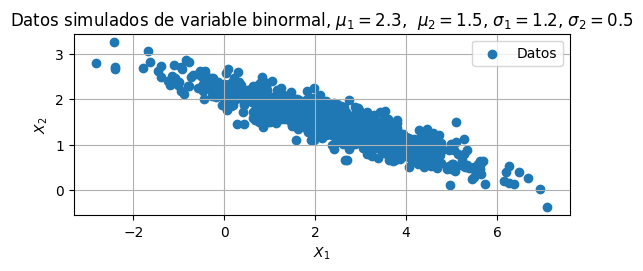

In [25]:
#Definimos los parámetros de la consigna
mu = np.array([2.3,1.5])
s1 = 1.5
s2 = 0.5
rho = 0.7
N = 1000

#Generamos la matriz de covarianza
cov = danatools.covariance_matrix_2d(s1, s2, -0.9)

#Generamos los datos
X = np.random.multivariate_normal(mu, cov, size= N)

#Visualizamos los datos generados
plt.scatter(X[:,0],X[:,1], label = 'Datos')
plt.xlabel('$X_1$')
plt.ylabel('$X_2$')
plt.grid()
plt.legend()
plt.axis('scaled')
plt.title('Datos simulados de variable binormal, $\mu_1 = 2.3$,  $\mu_2 = 1.5$, $\sigma_1 = 1.2$, $\sigma_2 = 0.5$')

Para ver cuántos puntos caen adentro, usamos la ayuda de que un punto $(x_1, x_2)$ pertenece a la elipse $r\sigma$ si la forma cuadrática asociada $q(x_1, x_2) ≤ r$.

Para calcular la forma cuadrática $q$, podemos escribirla como función de $x_1,x_2$, o podemos también usar la expresión vista en clase

$$q=(x-\mu)^T A (x-\mu)$$

donde $A$ es la matriz hessiana. En clase encontramos la expresión analítica, que podríamos escribir a mano, pero también mostramos que $A$  es la inversa de la matriz de covarianza, que ya tenemos calculada.

En esta celda calculamos $A$, y usamos la expresión de arriba para calcular $q$.

In [23]:
#Quiero calcular Q. Entiendo que hay 2 formas, definiendo Q(x1,x2) y evaluar para cada dato o hacer el producto matricial
#Lo segundo me pareció menos choclo, me pelee un poco para que quede de la dimensión que corresponde, pero entiendo que está bien así, al menos da lo que debería dar

A = np.linalg.inv(cov) #Matriz hessiana

q = np.sum((X-mu).T*(A@(X-mu).T),axis = 0)

#la fracción que está adentro de la elipse 1sigma es
n_1sigma = np.count_nonzero(q<1)/N

print(n_1sigma) #debería dar ~0.39 (se puede mostrar haciendo un cambio de variables de Q a Chi_2 ^2 y calcular la acumulada F_2(1))

0.382


La expresión analítica de $q(x_1,x_2)$ es

$$q(x_1,x_2) = \left(\frac{x_{1}-\mu_{1}}{\sigma_{1}}\right)^{2}+\left(\frac{x_{2}-\mu_{2}}{\sigma_{2}}\right)^{2}$$

Puede verse que haciendo primero un cambio de variables para estandarizar cada término, y después notando que la expresión es una suma de variables al cuadrado, entonces $q(x_1,x_2) \sim \chi_2^2$.

Entonces, la probabilidad de que un par $(x_1,x_2)$ esté adentro de la elipse $r\sigma$ equivale a evaluar la distribución acumulada de una variable $\chi_2^2$, que es

$$F_2(q)=1-e^{-q/2}.$$

En particular, para la elipse $1\sigma$, es

$$F_2(1)=1-e^{-1/2}≈ 0.39,$$ 

que es cercano al valor obtenido para 1000 puntos, y esperamos que tienda a el valor teórico aumentando el número de puntos.

Por último, Si la probabilidad de obtener un punto en la elipse es $P≈0.39$ entonces esperamos que de $N$ puntos totales, $Np\approx 4$ caigan en la elipse.

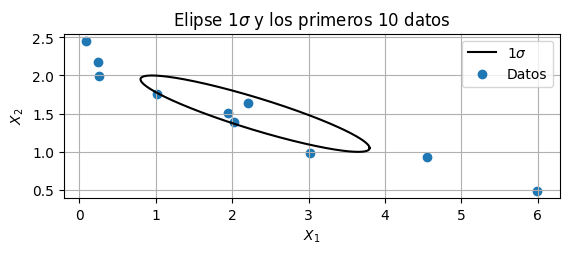

In [24]:
fig, ax = plt.subplots()
#grafico la elipse 1sigma
x, y = danatools.get_ellipse(mu, cov, nsigma=1)
ax.plot(x, y, color = 'black', label='$1\sigma$')
#y los primeros 10 datos como pide el tp, en promedio deberían caer 4 adentro pero
#puede fallar
ax.set_title('Elipse $1\sigma$ y los primeros 10 datos')

ax.scatter(X[:10,0],X[:10,1], label = 'Datos')

plt.axis('scaled')
ax.set_xlabel('$X_1$')
ax.set_ylabel('$X_2$')
ax.grid()

ax.legend()

## Conclusiones

En resumen, simulamos una variable binormal, calculamos la fracción de datos que caen en la elipse $1\sigma$ y vimos que se asemeja a la cantidad esperada usando la función acumulada de una distribución $\chi_2^2$.

Además, graficamos los primeros 10 datos, y obtuvimos una cantidad cercana a lo esperado de puntos dentro de la elipse (aunque puede variar en cada corrida del notebook).